In [49]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Pathways 
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "brownian_path.pdf"

In [50]:
""" Global parameters """

# Answer to the universe and everything
rng = np.random.default_rng(42)

# Input parameters 
S0 = 100.0
mu = 0.05
sigma = 0.2
T = 1.0
n_steps = 1000

In [51]:
""" Making some Brownian motion """

# Calculate Geometric Brownian Motion
dt = T / n_steps
t = np.linspace(0.0, T, n_steps + 1)
n_paths = 1000

# Generate random increments (n_paths x n_steps)
dW = rng.normal(0, np.sqrt(dt), (n_paths, n_steps))

# Calculate log returns and cumulate
log_returns = (mu - 0.5 * sigma**2) * dt + sigma * dW
S = S0 * np.exp(np.hstack([np.zeros((n_paths, 1)), np.cumsum(log_returns, axis=1)]))

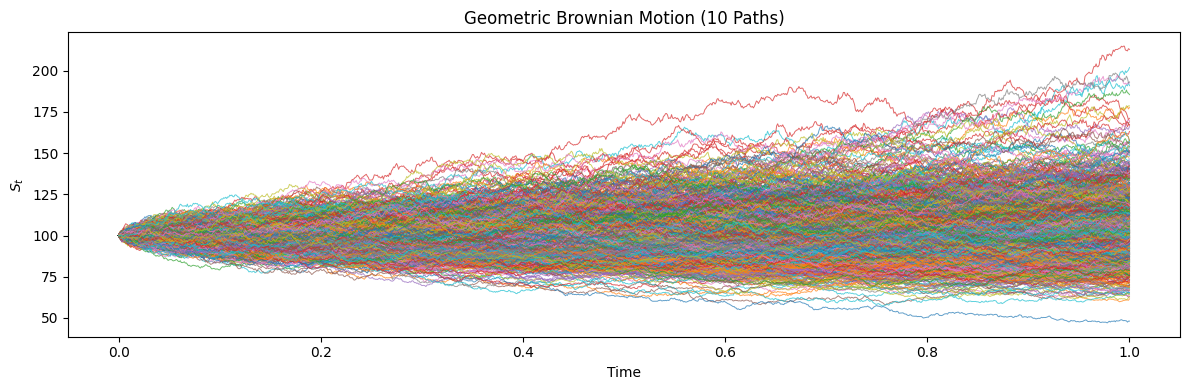

In [52]:
""" Plotting """

# Setting up the figure and axes
fig, ax = plt.subplots(figsize=(12,4))

# Plot all paths (transpose so each row becomes a line)
for i in range(n_paths):
    ax.plot(t, S[i], alpha=0.7, linewidth=0.7)

# Title, axes titles, and grid
ax.set_title("Geometric Brownian Motion (10 Paths)")
ax.set_xlabel("Time")
ax.set_ylabel(f"$S_t$")

# Tight layout
fig.tight_layout()

# Saving and showing the figure
fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()